# 01 · Data Cleaning & Feature Engineering

**Project:** Airbnb Price Drivers & Market Analysis — Amsterdam
**Source:** [Inside Airbnb](https://insideairbnb.com/get-the-data/) detailed listings, Amsterdam, scraped 15–24 June 2026.

**Goal of this notebook:** turn the raw 90-column scrape into a clean, analysis-ready table of *actively priced* listings, with every cleaning decision justified and row counts printed at each step.

**Note:** the `price` column carries a `$` sign, but the embedded price quote (`price_quote_raw`) states `"currency": "EUR"`. All prices in this project are **euros per night**.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import BLUE, DATA_PROCESSED, DATA_RAW, NEUTRAL, ORANGE, SURFACE, euro, save_fig, set_style

set_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

row_log = []  # (step, rows) audit trail


def log_rows(step, frame):
    row_log.append((step, len(frame)))
    prev = row_log[-2][1] if len(row_log) > 1 else len(frame)
    print(f"{step:<55} rows: {len(frame):>6,}  (change: {len(frame) - prev:+,})")

## 1. Load and inspect all columns

In [2]:
raw = pd.read_csv(DATA_RAW / "listings.csv.gz", low_memory=False)
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print("Scrape dates:", raw["last_scraped"].value_counts().to_dict())
log_rows("Raw file", raw)

Raw shape: 10,369 rows × 90 columns
Scrape dates: {'2026-06-16': 6450, '2026-06-24': 3420, '2026-06-15': 499}
Raw file                                                rows: 10,369  (change: +0)


In [3]:
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_%": (raw.isna().mean() * 100).round(1),
    "n_unique": raw.nunique(),
    "example": raw.apply(lambda s: str(s.dropna().iloc[0])[:45] if s.notna().any() else "—"),
})
# Hide examples of personal host details (names, profile links, bios)
personal = ["host_name", "host_url", "host_profile_url", "host_picture_url", "host_about", "host_profile_id"]
overview.loc[overview.index.isin(personal), "example"] = "(hidden)"
overview

,dtype,missing_%,n_unique,example
id,int64,0.0,10369,28871
listing_url,object,0.0,10369,https://www.airbnb.com/rooms/28871
scrape_id,int64,0.0,1,20260615212022
last_scraped,object,0.0,3,2026-06-16
source,object,0.0,2,previous scrape
name,object,0.0,10076,Comfortable double room
description,object,4.3,9640,Basic bedroom in the center of Amsterdam.
neighborhood_overview,float64,100.0,0,—
picture_url,object,0.0,10315,https://a0.muscache.com/pictures/160889/36234
host_id,int64,0.0,9104,124245


In [4]:
fully_empty = overview.index[overview["missing_%"] == 100].tolist()
print(f"{len(fully_empty)} columns are 100% empty in this scrape:\n", fully_empty)

13 columns are 100% empty in this scrape:
 ['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'instant_bookable']


**Observations**
- Several columns are completely empty in this scrape, including **`host_since`**, `host_response_rate`, `instant_bookable` and `neighbourhood_group_cleansed`. `host_since` is replaced by `hosts_time_as_host_years` / `_months`, which we use to compute host tenure.
- `bathrooms` is ~48% missing, but `bathrooms_text` (e.g. "1.5 shared baths") is almost complete, so we parse it.
- `price` is ~38% missing, examined below.
- URLs, picture links, free text and scrape metadata are not useful for price analysis.

## 2. Select useful columns
We keep the columns relevant to price, location, size, quality, host and availability. Extra review sub-scores (location, cleanliness, value) are kept because they may explain price better than the overall rating.

In [5]:
KEEP = [
    # identifiers
    "id", "name", "host_id", "host_name", "source", "last_scraped",
    # target
    "price",
    # property
    "room_type", "property_type", "accommodates", "bedrooms", "bathrooms_text", "amenities",
    # location
    "neighbourhood_cleansed", "latitude", "longitude",
    # booking rules & availability
    "minimum_nights", "availability_365", "estimated_occupancy_l365d",
    # reviews
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "review_scores_cleanliness", "review_scores_location", "review_scores_value",
    "first_review", "last_review",
    # host
    "host_is_superhost", "host_identity_verified",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "calculated_host_listings_count",
]
df = raw[KEEP].copy()
print(f"Kept {df.shape[1]} of {raw.shape[1]} columns")
log_rows("After column selection", df)

Kept 33 of 90 columns
After column selection                                  rows: 10,369  (change: +0)


## 3. Fix data types
- `price`: string like `"$1,200.00"` → float
- dates: `last_scraped`, `first_review`, `last_review` → datetime
- booleans: `"t"` / `"f"` → True / False (missing stays missing for now)

In [6]:
print("Price before:", df["price"].dropna().head(3).tolist())
df["price"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)
print("Price after: ", df["price"].dropna().head(3).tolist())

for col in ["last_scraped", "first_review", "last_review"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["host_is_superhost", "host_identity_verified"]:
    df[col] = df[col].map({"t": True, "f": False})

df.dtypes.to_frame("dtype").T

Price before: ['$94.00', '$313.67', '$440.27']
Price after:  [94.0, 313.67, 440.27]


,id,name,host_id,host_name,source,last_scraped,price,room_type,property_type,accommodates,bedrooms,bathrooms_text,amenities,neighbourhood_cleansed,latitude,longitude,minimum_nights,availability_365,estimated_occupancy_l365d,number_of_reviews,number_of_reviews_ltm,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,first_review,last_review,host_is_superhost,host_identity_verified,hosts_time_as_host_years,hosts_time_as_host_months,calculated_host_listings_count
dtype,int64,object,int64,object,object,datetime64[ns],float64,object,object,int64,float64,object,object,object,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64,datetime64[ns],datetime64[ns],object,object,float64,float64,int64


## 4. Missing values

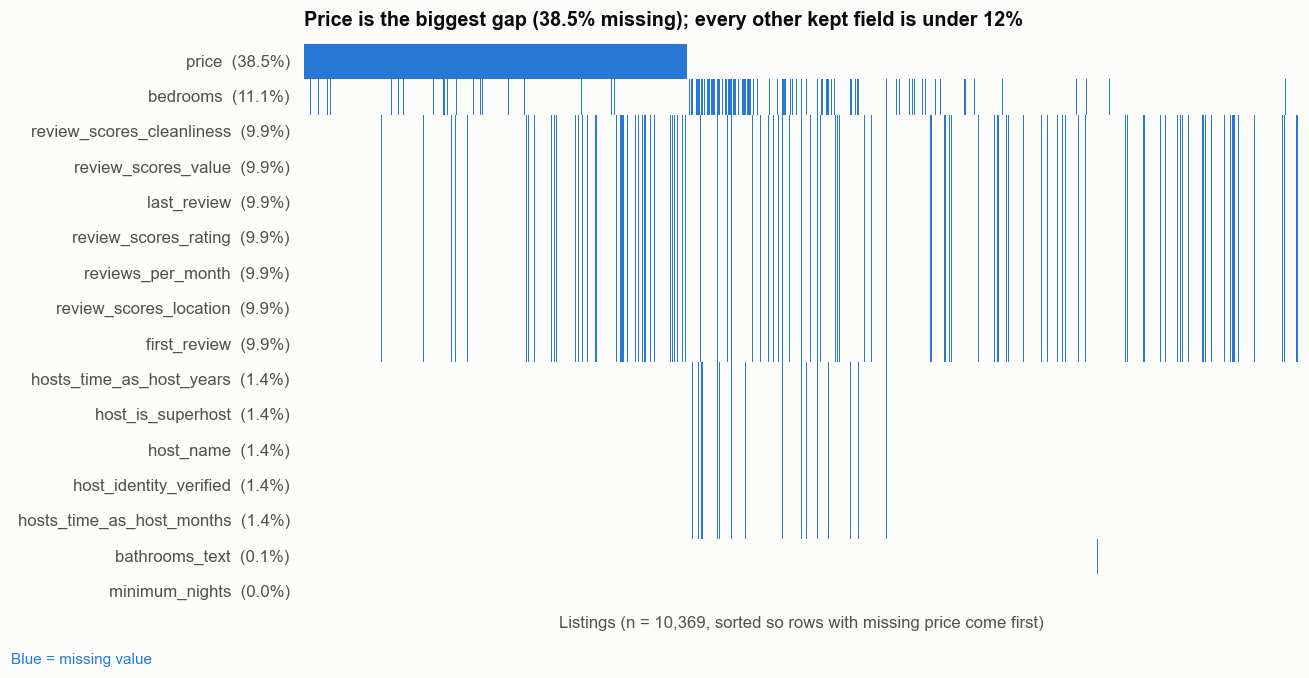

In [7]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(12, 6))
order = df.sort_values("price", na_position="first")[missing.index]
sns.heatmap(order.isna().T, cmap=ListedColormap([SURFACE, BLUE]), cbar=False, ax=ax,
            xticklabels=False, yticklabels=[f"{c}  ({missing[c]:.1f}%)" for c in missing.index])
ax.set_title(f"Price is the biggest gap ({missing['price']:.1f}% missing); every other kept field is under 12%")
ax.set_xlabel(f"Listings (n = {len(df):,}, sorted so rows with missing price come first)")
ax.set_ylabel("")
fig.text(0.01, -0.02, "Blue = missing value", color=BLUE, fontsize=10)
plt.tight_layout()
save_fig(fig, "01_missing_values_heatmap")
plt.show()

### 4a. Missing `price`: who are these listings?
Price is the target variable. Before dropping, we check whether the unpriced listings are a random subset or a distinct group.

In [8]:
no_price = df["price"].isna()
diag = pd.DataFrame({
    "Missing price": [no_price.sum(), (df.loc[no_price, "source"] == "previous scrape").mean() * 100,
                      df.loc[no_price, "availability_365"].mean(), df.loc[no_price, "number_of_reviews_ltm"].mean()],
    "Has price": [(~no_price).sum(), (df.loc[~no_price, "source"] == "previous scrape").mean() * 100,
                  df.loc[~no_price, "availability_365"].mean(), df.loc[~no_price, "number_of_reviews_ltm"].mean()],
}, index=["Listings", "% from 'previous scrape'", "Mean days available (next 365)", "Mean reviews last 12 months"]).round(1)
diag

,Missing price,Has price
Listings,3992.0,6377.0
% from 'previous scrape',97.2,9.8
Mean days available (next 365),6.4,148.3
Mean reviews last 12 months,1.9,12.8


**Decision: drop listings without a price.** The unpriced listings come mostly from a *previous* scrape, are open on average only ~6 days in the next year and receive few recent reviews. They are inactive listings with nothing to book, not random gaps. Imputing the target would invent data.

In [9]:
df = df[df["price"].notna()].copy()
log_rows("Drop listings with no price (inactive)", df)

Drop listings with no price (inactive)                  rows:  6,377  (change: -3,992)


### 4b. Remaining gaps

In [10]:
remaining = df.isna().sum()
remaining[remaining > 0].sort_values(ascending=False).to_frame("missing")

,missing
bedrooms,913
review_scores_rating,637
reviews_per_month,637
review_scores_cleanliness,637
first_review,637
review_scores_value,637
review_scores_location,637
last_review,637
host_is_superhost,138
host_name,138


| Column(s) | Decision | Justification |
|---|---|---|
| Host fields (`host_is_superhost`, tenure, …) | **Drop rows** | ~2% of rows; the host profile is unavailable, so tenure and superhost status cannot be recovered. |
| `minimum_nights` | **Drop rows** | A handful of rows; booking rules are unknown. |
| `bathrooms_text` | **Parse → `bathrooms`; fill gaps with median for same `accommodates`** | Bathroom count scales with capacity; very few rows affected. |
| `bedrooms` | **Fill with median for same `accommodates`** | ~14% missing (mostly studios and rooms). Group median keeps the size relationship; a `bedrooms_imputed` flag records it. |
| `review_scores_*`, `first/last_review` | **Keep as NaN + `has_reviews` flag** | Missing because the listing has *no reviews*. Filling with a mean would make new listings look like average performers. |
| `reviews_per_month` | **Fill with 0** | No reviews means zero reviews per month, which is the true value. |

In [11]:
df = df.dropna(subset=["host_is_superhost", "hosts_time_as_host_years"])
log_rows("Drop rows with no host profile", df)

df = df.dropna(subset=["minimum_nights"])
log_rows("Drop rows with no minimum_nights", df)

Drop rows with no host profile                          rows:  6,239  (change: -138)
Drop rows with no minimum_nights                        rows:  6,236  (change: -3)


In [12]:
# Bathrooms: parse the number from text; "half-bath" = 0.5; record shared baths
bt = df["bathrooms_text"].str.lower()
df["bathrooms"] = bt.str.extract(r"(\d+\.?\d*)")[0].astype(float)
df.loc[bt.str.contains("half", na=False) & df["bathrooms"].isna(), "bathrooms"] = 0.5
df["bath_shared"] = bt.str.contains("shared", na=False)
print("Unparsed bathrooms:", df["bathrooms"].isna().sum())

for col in ["bathrooms", "bedrooms"]:
    if col == "bedrooms":
        df["bedrooms_imputed"] = df["bedrooms"].isna()
    group_median = df.groupby("accommodates")[col].transform("median")
    df[col] = df[col].fillna(group_median).fillna(df[col].median())

df["has_reviews"] = df["number_of_reviews"] > 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df = df.drop(columns=["bathrooms_text"])

print(f"Bedrooms imputed for {df['bedrooms_imputed'].sum():,} listings")
log_rows("After filling bathrooms / bedrooms / reviews_per_month", df)
df.isna().sum()[lambda s: s > 0].to_frame("still missing (by design)")

Unparsed bathrooms: 8
Bedrooms imputed for 774 listings
After filling bathrooms / bedrooms / reviews_per_month  rows:  6,236  (change: +0)


,still missing (by design)
review_scores_rating,614
review_scores_cleanliness,614
review_scores_location,614
review_scores_value,614
first_review,614
last_review,614


## 5. Outliers: IQR method

Nightly prices are heavily right-skewed (a few luxury listings at several thousand euros). We use the **IQR rule** (remove values outside Q1 − 1.5·IQR and Q3 + 1.5·IQR), applied to **log price** rather than raw price:
- On the raw scale the upper fence sits low, so the rule would remove legitimate large family homes and canal houses.
- On the log scale the distribution is roughly symmetric, so the fences catch only real anomalies: implausibly cheap entries (likely placeholder prices) and extreme luxury listings.

Both versions are computed below for comparison.

In [13]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

raw_lo, raw_hi = iqr_bounds(df["price"])
log_lo, log_hi = iqr_bounds(np.log1p(df["price"]))
log_lo_eur, log_hi_eur = np.expm1(log_lo), np.expm1(log_hi)

raw_out = ~df["price"].between(raw_lo, raw_hi)
log_out = ~df["price"].between(log_lo_eur, log_hi_eur)
print(f"Raw-price IQR fences: €{max(raw_lo, 0):,.0f} – €{raw_hi:,.0f}  → would remove {raw_out.sum():,} listings ({raw_out.mean():.1%})")
print(f"Log-price IQR fences: €{log_lo_eur:,.0f} – €{log_hi_eur:,.0f}  → removes {log_out.sum():,} listings ({log_out.mean():.1%})")
print("\nRoom type of listings the raw-price rule would remove:")
print(df.loc[raw_out, "room_type"].value_counts().to_string())
print(f"Median capacity of those listings: {df.loc[raw_out, 'accommodates'].median():.0f} guests (overall: {df['accommodates'].median():.0f})")

Raw-price IQR fences: €0 – €723  → would remove 332 listings (5.3%)
Log-price IQR fences: €77 – €1,142  → removes 150 listings (2.4%)

Room type of listings the raw-price rule would remove:
room_type
Entire home/apt    316
Private room        16
Median capacity of those listings: 4 guests (overall: 2)


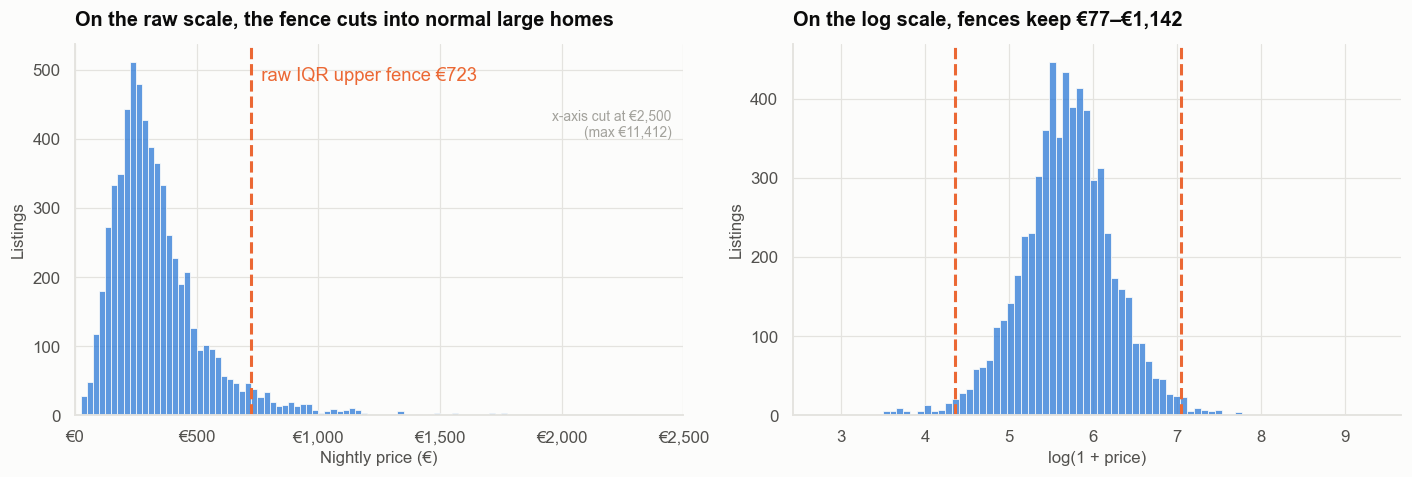

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["price"], bins=100, binrange=(0, 2500), color=BLUE, ax=axes[0], edgecolor=SURFACE, linewidth=0.5)
for x in [raw_hi]:
    axes[0].axvline(x, color=ORANGE, ls="--", lw=2)
axes[0].text(raw_hi, axes[0].get_ylim()[1] * 0.9, f"  raw IQR upper fence €{raw_hi:,.0f}", color=ORANGE)
axes[0].set(title="On the raw scale, the fence cuts into normal large homes", xlabel="Nightly price (€)", ylabel="Listings",
            xlim=(0, 2500))
axes[0].text(2450, axes[0].get_ylim()[1] * 0.75, f"x-axis cut at €2,500\n(max €{df['price'].max():,.0f})",
             ha="right", color=NEUTRAL, fontsize=9)
axes[0].xaxis.set_major_formatter(euro)

sns.histplot(np.log1p(df["price"]), bins=80, color=BLUE, ax=axes[1], edgecolor=SURFACE, linewidth=0.5)
for x in [log_lo, log_hi]:
    axes[1].axvline(x, color=ORANGE, ls="--", lw=2)
axes[1].set(title=f"On the log scale, fences keep €{log_lo_eur:,.0f}–€{log_hi_eur:,.0f}",
            xlabel="log(1 + price)", ylabel="Listings")
plt.tight_layout()
save_fig(fig, "01_outlier_fences")
plt.show()

In [15]:
df = df[~log_out].copy()
df["log_price"] = np.log1p(df["price"])
log_rows("Remove price outliers (IQR on log price)", df)

Remove price outliers (IQR on log price)                rows:  6,086  (change: -150)


Sanity check: listings that require stays of over a year (`minimum_nights > 365`) are not short-term rentals and would be removed. After the steps above, none remain.

In [16]:
print("Listings with minimum_nights > 30:", (df["minimum_nights"] > 30).sum())
df = df[df["minimum_nights"] <= 365]
log_rows("Remove minimum_nights > 365", df)

Listings with minimum_nights > 30: 7
Remove minimum_nights > 365                             rows:  6,086  (change: +0)


## 6. Feature engineering

| Feature | Definition |
|---|---|
| `host_tenure_years` | `hosts_time_as_host_years + months / 12` (replaces the empty `host_since`) |
| `host_since` | approximate start date = scrape date − tenure (for supply-growth analysis) |
| `amenity_count` | number of amenities in the listing's amenity list |
| `price_per_person` | price / accommodates |
| `is_multi_host` | host manages more than one listing in Amsterdam (`calculated_host_listings_count > 1`) |
| `dist_centre_km` | straight-line distance to Dam Square (52.3731 N, 4.8926 E) |
| `amen_*` | flags for selected amenities guests often filter on |

In [17]:
df["host_tenure_years"] = (df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12).round(2)
df["host_since"] = df["last_scraped"] - pd.to_timedelta(df["host_tenure_years"] * 365.25, unit="D")
df["host_since_year"] = df["host_since"].dt.year

amen_lists = df["amenities"].apply(lambda s: [a.lower() for a in json.loads(s)])
df["amenity_count"] = amen_lists.str.len()

df["price_per_person"] = (df["price"] / df["accommodates"]).round(2)
df["is_multi_host"] = df["calculated_host_listings_count"] > 1

# Haversine distance to Dam Square
lat0, lon0 = np.radians(52.3731), np.radians(4.8926)
lat, lon = np.radians(df["latitude"]), np.radians(df["longitude"])
a = np.sin((lat - lat0) / 2) ** 2 + np.cos(lat0) * np.cos(lat) * np.sin((lon - lon0) / 2) ** 2
df["dist_centre_km"] = (2 * 6371 * np.arcsin(np.sqrt(a))).round(3)

AMENITY_FLAGS = {
    "amen_wifi": "wifi", "amen_kitchen": "kitchen", "amen_washer": "washer",
    "amen_dishwasher": "dishwasher", "amen_workspace": "dedicated workspace",
    "amen_self_checkin": "self check-in", "amen_balcony": "patio or balcony",
    "amen_bathtub": "bathtub", "amen_waterfront": "waterfront",
    "amen_air_conditioning": "air conditioning", "amen_elevator": "elevator",
    "amen_free_parking": "free parking",
}
for col, key in AMENITY_FLAGS.items():
    df[col] = amen_lists.apply(lambda lst, k=key: any(k in a for a in lst))

df = df.drop(columns=["amenities", "hosts_time_as_host_years", "hosts_time_as_host_months"])
log_rows("After feature engineering", df)

df[["host_tenure_years", "host_since_year", "amenity_count", "price_per_person", "dist_centre_km"]].describe().round(2)

After feature engineering                               rows:  6,086  (change: +0)


,host_tenure_years,host_since_year,amenity_count,price_per_person,dist_centre_km
count,6086.00,6086.00,6086.00,6086.00,6086.00
mean,6.05,2019.89,33.10,118.54,2.67
std,4.33,4.34,15.24,54.63,1.67
min,0.00,2011.00,0.00,13.75,0.05
25%,2.08,2016.00,22.00,80.40,1.51
50%,5.67,2020.00,33.00,110.00,2.41
75%,9.83,2024.00,44.00,145.50,3.34
max,15.42,2026.00,99.00,552.00,11.21


In [18]:
df[list(AMENITY_FLAGS)].mean().mul(100).round(1).sort_values(ascending=False).to_frame("% of listings")

,% of listings
amen_wifi,98.7
amen_kitchen,81.8
amen_washer,78.6
amen_workspace,56.2
amen_dishwasher,55.2
amen_balcony,40.9
amen_self_checkin,33.5
amen_bathtub,27.7
amen_waterfront,18.1
amen_air_conditioning,16.9


In [19]:
print(f"Multi-listing hosts own {df['is_multi_host'].mean():.1%} of listings")
print(df["room_type"].value_counts().to_string())

Multi-listing hosts own 21.9% of listings
room_type
Entire home/apt    4682
Private room       1378
Hotel room           25
Shared room           1


## 7. Row-count audit and save

In [20]:
audit = pd.DataFrame(row_log, columns=["step", "rows"])
audit["change"] = audit["rows"].diff().fillna(0).astype(int)
audit["% of raw"] = (audit["rows"] / audit["rows"].iloc[0] * 100).round(1)
audit

,step,rows,change,% of raw
0,Raw file,10369,0,100.0
1,After column selection,10369,0,100.0
2,Drop listings with no price (inactive),6377,-3992,61.5
3,Drop rows with no host profile,6239,-138,60.2
4,Drop rows with no minimum_nights,6236,-3,60.1
5,After filling bathrooms / bedrooms / reviews_p...,6236,0,60.1
6,Remove price outliers (IQR on log price),6086,-150,58.7
7,Remove minimum_nights > 365,6086,0,58.7
8,After feature engineering,6086,0,58.7


In [21]:
out = DATA_PROCESSED / "listings_clean.csv"
df.to_csv(out, index=False)
print(f"Saved {df.shape[0]:,} rows × {df.shape[1]} columns → {out.relative_to(ROOT)}")
print(f"Price: median €{df['price'].median():,.0f}, mean €{df['price'].mean():,.0f}, range €{df['price'].min():,.0f}–€{df['price'].max():,.0f}")

Saved 6,086 rows × 53 columns → data\processed\listings_clean.csv
Price: median €297, mean €336, range €77–€1,142


## Key Takeaways

- **Raw → clean:** 10,369 listings → **6,086** analysis-ready listings (58.7% kept), 33 of 90 columns kept; 24 new columns created (incl. 12 amenity flags) and 4 raw helper columns dropped, giving 53 columns.
- **Missing price was not random:** the 3,992 unpriced listings (38.5%) were 97.2% from a *previous* scrape and open only 6.4 days/year on average, against 148.3 for priced listings. They are inactive, so dropping them is the correct choice.
- **Outliers:** the IQR rule on log price keeps €77–€1,142/night and removes 150 listings (2.4%). The same rule on raw price would have removed 332 (5.3%), 316 of them entire homes with a median capacity of 4 guests, i.e. normal family homes.
- **Imputation kept minimal:** bedrooms imputed for 774 listings (group median by capacity, flagged); 614 listings with no reviews keep NaN scores plus a `has_reviews` flag rather than invented ratings.
- **The cleaned market:** median **€297/night** (mean €336); 4,682 entire homes vs 1,378 private rooms; median host tenure 5.7 years; median 33 amenities; **21.9%** of listings belong to multi-listing hosts.